In [125]:
from sklearn.datasets import load_breast_cancer
import numpy as np

In [127]:
data = load_breast_cancer()

In [129]:
x = data.data[:,[7,20]]
y = data.target

In [131]:
from sklearn.model_selection import train_test_split 

In [133]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42
                                                )

In [135]:
x.shape
#y.shape

(569, 2)

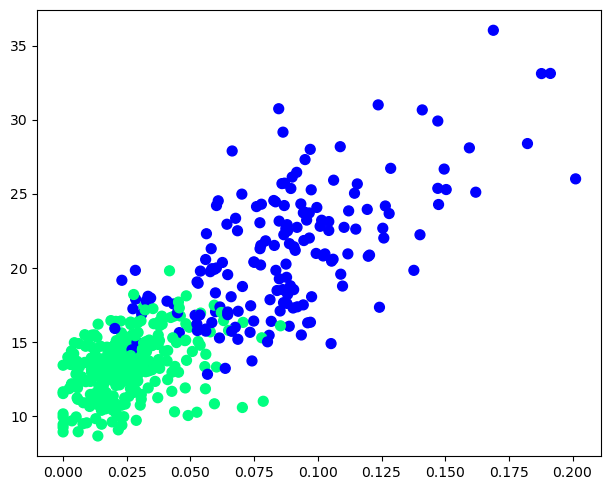

In [137]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,cmap='winter',s=50)

plt.tight_layout()
plt.show()

In [139]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np

In [143]:
model = LogisticRegression()

In [145]:
model.fit(x_train,y_train)

LogisticRegression()

In [147]:
y_pred = model.predict(x_test)

In [149]:
print(model.intercept_)
print(model.coef_)

[0.46073139]
[[-2.46792471 -2.88476488]]


In [151]:
b = model.intercept_[0] # these values from Logistic Regression
w1 = model.coef_[0][0]
w2 = model.coef_[0][1]

In [153]:
 x1 = np.linspace(x_train[:,0].min(),x_train[:,0].max(),100)

In [155]:
x2 = -(b + w1*x1)/w2

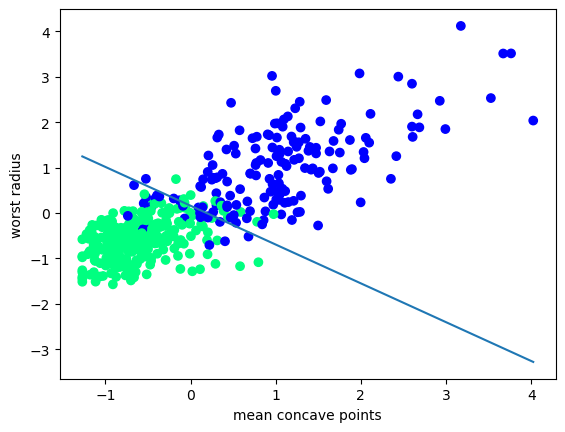

In [157]:
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap="winter"
)

plt.plot(x1, x2)

plt.xlabel(data.feature_names[7])
plt.ylabel(data.feature_names[20])
plt.show()

In [160]:
def step(z):
    return 1 if z>0 else 0

def perceptron(x,y):
    
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.01
    
    for i in range(10000):
        j = np.random.randint(0, x.shape[0])
        y_hat = step(np.dot(x[j],weights))
        weights = weights + lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

        
        
       
 

In [162]:
intercept1_,coef1_ = perceptron(x_train,y_train)

In [164]:
print(coef1_)
print(intercept1_)



[-0.00410685 -0.01759258]
-7.528699885739343e-16


In [166]:
b = intercept1_ # these values from Logistic Regression
w1 = coef1_[0]
w2 = coef1_[1]

In [168]:
x1_prec = np.linspace(x_train[:, 0].min(), x_train[:, 0].max(), 100)
x2_prec = -(b + w1 * x1_prec) / w2

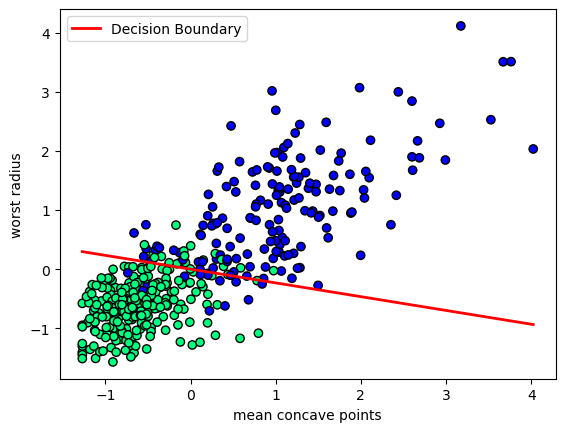

In [170]:
#Plot Perceptron decision boundary
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="winter", edgecolors='k')
plt.plot(x1_prec, x2_prec, color='red', linewidth=2, label='Decision Boundary')
plt.xlabel(data.feature_names[7])
plt.ylabel(data.feature_names[20])
plt.legend()
plt.show()

In [172]:

def gd(x,y):

    x=np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.5
    for i  in range(10000):
        y_hat=sigmoid(np.dot(x,weights))
        weights = weights + lr*(np.dot((y-y_hat),x)/x.shape[0])

    return weights[1:],weights[0]


def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [174]:
coef_2,intercept_2 = gd(x_train,y_train)

In [176]:
b = intercept_2 # these values from updated percceptron with sigmoid,logloss and with gd
w1 = coef_2[0]
w2 = coef_2[1]

In [178]:
 x1_prec2 = np.linspace(x_train[:,0].min(),x_train[:,0].max(),100)
x2_prec2 = -(b + w1 * x1_prec2) / w2


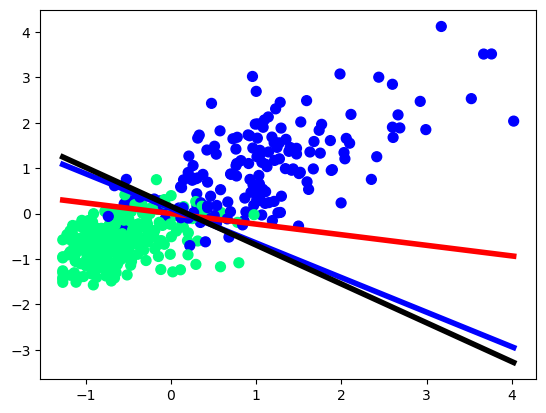

In [180]:
plt.plot(x1_prec, x2_prec, color='red', linewidth= 4, label='Decision Boundary with peceptron')
plt.plot(x1_prec2, x2_prec2, color='blue', linewidth=4, label='Decision Boundary with  final updated perceptron')
plt.plot(x1, x2,color = 'black', linewidth = 4, label ='Logistic Regression')
plt.scatter(x_train[:,0],x_train[:,1],c=y_train ,cmap = 'winter', s=50)